# polyfit — Statistical Guide

This notebook explains **what polyfit does statistically** and how to interpret its output.
It assumes familiarity with the chemistry (Mayo-Lewis terminal model, reactivity ratios $r_1$, $r_2$)
but no prior knowledge of maximum-likelihood estimation or Bayesian inference.

**Covered topics:**
1. Why ordinary least squares is insufficient
2. The Errors-in-Variables (EVM) covariance framework
3. Maximum-likelihood estimation and the chi-squared function
4. Two types of error bar — Gaussian vs. true credible intervals
5. Running a Mayo-Lewis (low-conversion) fit
6. Reading numbers: best-fit, error bars, correlation
7. The corner plot — joint posterior and 1D marginals
8. Residual diagnostics
9. The PTE goodness-of-fit test
10. The Skeist model (high conversion)
11. Reporting results for publication

---
**Reference:** R. Reischke, *Macromolecular Theory and Simulations* **32** (2023) 2200063.  
DOI: [10.1002/mats.202200063](https://onlinelibrary.wiley.com/doi/10.1002/mats.202200063)

---
## 1 — Why not just minimise the sum of squared residuals?

Ordinary least squares (OLS) minimises $\sum_i (F_{2,i}^\mathrm{obs} - F_{2,i}^\mathrm{model})^2$.
This is statistically correct only when:

1. **errors exist only in $F_2$** (the dependent variable), and
2. all data points have the **same** uncertainty.

In practice neither is true for copolymerization experiments:

- The feed composition $f_2$ is measured (by weighing or NMR) and carries an error.
- Different data points often have different uncertainties.
- Errors in $f_2$ and $F_2$ may be correlated if both come from the same NMR spectrum.

Ignoring these facts gives **biased** estimates of $r_1$, $r_2$ and **overconfident** error bars.
This is the fundamental problem with classical Fineman-Ross and Kelen-Tüdős linearisations.

polyfit solves this with **maximum-likelihood estimation** (MLE) and a full error propagation
that accounts for uncertainties in all measured quantities simultaneously.

---
## 2 — The Errors-in-Variables (EVM) covariance framework

### Covariance matrices

For $N$ data points the measurement uncertainties are encoded in three $N\times N$ matrices:

| Matrix | Symbol | Meaning |
|--------|--------|---------|
| X covariance | $C_{XX}$ | Variances (and covariances) of the feed compositions $f_2$ |
| Y covariance | $C_{YY}$ | Variances (and covariances) of the copolymer compositions $F_2$ |
| XY covariance | $C_{XY}$ | Cross-covariances between $f_2$ and $F_2$ errors |

For the most common case — independent data points with a constant relative uncertainty — every
matrix is diagonal and reduces to a single number:

$$C_{XX} = \sigma_{f_2}^2\, I, \qquad C_{YY} = \sigma_{F_2}^2\, I$$

In `input.ini` this is written as:

```ini
X_covariance = rel 0.05   # 5 % relative error on every f2 data point
Y_covariance = rel 0.05   # 5 % relative error on every F2 data point
```

If uncertainties differ per point, or you have correlations, supply a full $N\times N$ matrix file:

```ini
X_covariance = data/X_covariance.txt
```

### The effective covariance matrix $R$

polyfit does not fit against $F_2$ alone — it propagates the $f_2$ uncertainty through the
model via its derivative and combines all three covariance matrices into one **effective
covariance matrix** $R$:

$$R = C_{YY} - C_{XY}\,T - T\,C_{XY}^\top + T\,C_{XX}\,T, \qquad T_{ii} = \frac{\partial F_2}{\partial f_2}\bigg|_{f_{2,i}}$$

**In plain terms:** $T$ tells the fitter how much a small error in $f_2$ translates into a
shift in the *predicted* $F_2$.  On a steep part of the composition curve a small $f_2$ error
matters a lot; on a flat part it barely matters.

### Why $C_{XY}$ matters

If $f_2$ and $F_2$ are both read from the same NMR spectrum, an integration error shifts both
values simultaneously — their errors are correlated.  Setting $C_{XY} \neq 0$ removes this
double-counting and gives tighter, more accurate error bars.
For most experimental set-ups `XY_covariance = rel 0.0` is a safe default.

---
## 3 — Maximum-likelihood estimation

### The chi-squared function

Assuming Gaussian measurement noise the log-likelihood is:

$$-2\ln\mathcal{L}(r_1,r_2) = \ln\det R(r_1,r_2) + \tilde{\mathbf{Y}}^\top R^{-1}(r_1,r_2)\,\tilde{\mathbf{Y}} \equiv \chi^2$$

where $\tilde{Y}_i = F_{2,i}^\mathrm{obs} - F_{2,i}^\mathrm{model}(r_1,r_2,f_{2,i})$.

Note that $R$ itself depends on $(r_1,r_2)$ through $T$, so even the $\ln\det R$ term changes
during the optimisation — this is what makes EVM different from weighted least squares.

### Best-fit values

The **maximum-likelihood estimates** $\hat{r}_1$, $\hat{r}_2$ minimise $\chi^2$.
polyfit uses the Nelder-Mead simplex algorithm — no gradient required.

---
## 4 — Two types of error bar

### Type 1: Gaussian (symmetric) from the Fisher matrix

The curvature of $\chi^2$ at the MLE quantifies how sharp the minimum is.
This curvature is the **Fisher information matrix** $\mathcal{F}$:

$$\mathcal{F}_{ij} = -\frac{\partial^2\ln\mathcal{L}}{\partial\theta_i\,\partial\theta_j}\bigg|_{\hat\theta}$$

Its inverse gives the Gaussian covariance:

$$\sigma_{r_1} = \sqrt{(\mathcal{F}^{-1})_{22}}, \qquad \sigma_{r_2} = \sqrt{(\mathcal{F}^{-1})_{11}}$$

This is fast and gives the *minimum possible* uncertainty for an unbiased estimator — but only
if the $\chi^2$ surface near the minimum is well approximated by a paraboloid (Gaussian posterior).

### Type 2: True credible intervals from the full posterior

polyfit evaluates $\chi^2(r_1,r_2)$ on an $N_\text{inter}\times N_\text{inter}$ grid.
The **posterior probability map** is:

$$P(r_1,r_2\,|\,\text{data}) \propto \exp\!\left(-\tfrac{1}{2}\chi^2\right)$$

From this map, polyfit finds the contour level $P_c$ such that the probability above it
integrates to exactly $68.3\,\%$, $95.4\,\%$, or $99.7\,\%$ — the **credible regions**.

The **1D marginal** for each parameter is obtained by integrating out the other:

$$P(r_1\,|\,\text{data}) = \int P(r_1,r_2)\,\mathrm{d}r_2$$

Asymmetric error bars are the 16th and 84th percentiles of these marginals.

### Which to report?

| Situation | Recommendation |
|-----------|----------------|
| Gaussian ≈ true (within ±20 %) | Either acceptable; prefer true credible intervals |
| Gaussian < true | Posterior is non-Gaussian — **must use true intervals** |
| MLE near a physical boundary | Posterior is skewed — **must use true intervals** |

> **For publication:** always report the MLE as the central value and the asymmetric true
> credible intervals, with the joint 2D contour plot as a figure.

---
## 5 — Running a fit: Mayo-Lewis (low conversion)

In [1]:
import os, sys

# Run from the polyfit root directory
if os.path.basename(os.getcwd()) == 'examples':
    os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from source.fit_model import FitModel
from source.models import mayo_lewis, mayo_lewis_deriv

print('polyfit root:', os.getcwd())
print('Setup complete.')

polyfit root: /Users/robert/Documents/Git/polyfit
Setup complete.


### The example config file

We use `examples/mayo_lewis_example.ini` which points to `data/data.txt` (5 % relative
uncertainty on both $f_2$ and $F_2$, independent errors).

In [2]:
with open('examples/mayo_lewis_example.ini') as fh:
    print(fh.read())

# polyfit — example config for the Mayo-Lewis instantaneous model
# Use this when fractional conversion X < ~5 %.
#
# Run with:   python main.py examples/mayo_lewis_example.ini
#
# ──────────────────────────────────────────────────────────────────────────

[data_structure]

# Path to the data file (relative to the polyfit root directory).
# Supported formats:
#   Plain text (.txt) — 2 columns: X  F
#   CSV 4-col  (.csv) — f0, X, F, dF
#   CSV 5-col  (.csv) — f0, X, dX, F, dF           (EVM: errors on both)
#   CSV 6-col  (.csv) — f0, X, dX, F, dF, df0      (EVM + f0 uncertainty)
file_data = data/data.txt

# false = Mayo-Lewis instantaneous model  (use when X < ~5 %)
# true  = Skeist integrated model         (use when X > ~5 %)
high_conversion = false

# Measurement uncertainties — only used for plain-text files.
# For CSV files the delta columns in the file take priority.
#
# Formats:
#   rel 0.05        — 5 % relative uncertainty on every point
#   abs 0.02        — constant absolute 

### Model functions

polyfit needs two callables:

- `model(parameters, x)` — the forward model $F_2(f_2;\,r_2,r_1)$.
- `dmodel(parameters, x)` — the derivative $\partial F_2/\partial f_2$, required to build $T$.

The built-in Mayo-Lewis implementations in `source.models` are used directly:

In [3]:
# Quick sanity check: ideal copolymerisation (r1=r2=1) must give F2 = f2
f_test = np.linspace(0.1, 0.9, 9)
assert np.allclose([mayo_lewis([1.0, 1.0], f) for f in f_test], f_test, atol=1e-12)
print('Sanity check passed: F2 = f2 when r1 = r2 = 1.')

Sanity check passed: F2 = f2 when r1 = r2 = 1.


Optimization terminated successfully.
         Current function value: -62.639997
         Iterations: 79
         Function evaluations: 150
creating posterior grid
  100/100 rows


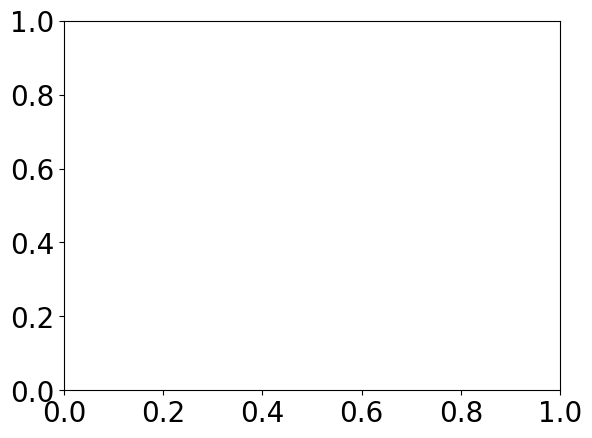

In [4]:
import os; os.makedirs('output', exist_ok=True)

fit = FitModel(mayo_lewis, mayo_lewis_deriv, 'examples/mayo_lewis_example.ini')

---
## 6 — Reading the numbers

In [5]:
r2_bf, r1_bf = fit.best_fit

# Gaussian errors from the inverse Fisher matrix
invF    = np.linalg.inv(fit.fisher_at_bf)
sig_r2  = np.sqrt(invF[0, 0])
sig_r1  = np.sqrt(invF[1, 1])
corr    = invF[0, 1] / (sig_r2 * sig_r1)   # parameter correlation coefficient

# True asymmetric 68 % credible intervals from the marginal CDFs
r2_lo = r2_bf - fit.p1_cdf_marginal_spline(0.159)
r2_hi = fit.p1_cdf_marginal_spline(0.841) - r2_bf
r1_lo = r1_bf - fit.p2_cdf_marginal_spline(0.159)
r1_hi = fit.p2_cdf_marginal_spline(0.841) - r1_bf

chi2_min = 2.0 * fit.max_func
N        = fit.number_of_data_points
chi2_dof = chi2_min / max(N - 2, 1)

print('Maximum-likelihood estimates')
print('=' * 56)
print(f'  r2 = {r2_bf:.4f}')
print(f'       Gaussian   : ± {sig_r2:.4f}')
print(f'       True 68 %  : −{r2_lo:.4f}  /  +{r2_hi:.4f}')
print()
print(f'  r1 = {r1_bf:.4f}')
print(f'       Gaussian   : ± {sig_r1:.4f}')
print(f'       True 68 %  : −{r1_lo:.4f}  /  +{r1_hi:.4f}')
print()
print(f'  Parameter correlation  ρ(r2, r1) = {corr:+.3f}')
print(f'  χ²_min = {chi2_min:.3f}   N = {N}   χ²/dof = {chi2_dof:.3f}')
print()

# How well does the Gaussian approximation hold?
print('Gaussian vs. true errors')
print('-' * 40)
for name, sig, lo, hi in [('r2', sig_r2, r2_lo, r2_hi), ('r1', sig_r1, r1_lo, r1_hi)]:
    avg_true = 0.5 * (lo + hi)
    ratio    = sig / avg_true if avg_true > 0 else float('nan')
    if 0.8 < ratio < 1.2:
        verdict = 'Gaussian approximation is good'
    else:
        verdict = 'non-Gaussian posterior — use true credible intervals'
    print(f'  {name}: Gaussian/true = {ratio:.2f}  →  {verdict}')

Maximum-likelihood estimates
  r2 = 0.0165
       Gaussian   : ± 0.0206
       True 68 %  : −0.0053  /  +0.0254

  r1 = 5.0847
       Gaussian   : ± 0.3355
       True 68 %  : −0.1289  /  +0.2449

  Parameter correlation  ρ(r2, r1) = +0.338
  χ²_min = -125.280   N = 20   χ²/dof = -6.960

Gaussian vs. true errors
----------------------------------------
  r2: Gaussian/true = 1.34  →  non-Gaussian posterior — use true credible intervals
  r1: Gaussian/true = 1.79  →  non-Gaussian posterior — use true credible intervals


### Interpreting the correlation coefficient $\rho$

The off-diagonal element of $\mathcal{F}^{-1}$ gives the **parameter correlation**:

$$\rho(r_2, r_1) = \frac{(\mathcal{F}^{-1})_{01}}{\sigma_{r_2}\,\sigma_{r_1}} \in [-1, 1]$$

| $|\rho|$ | Meaning |
|---------|----------|
| < 0.3 | Weakly correlated — parameters are determined nearly independently |
| 0.3 – 0.7 | Moderately correlated — report as 2D contour, not just error bars |
| > 0.7 | Strongly correlated — many $(r_1,r_2)$ pairs fit nearly equally well |

A large $|\rho|$ means the contour is elongated along the correlation direction.
In that case individual error bars are misleading — show the 2D joint posterior.

### What $\chi^2/\text{dof}$ tells you

The reduced chi-squared $\chi^2/\text{dof}$ (with $\text{dof} = N - 2$) should be close to 1.0
if the model and the uncertainty budget are both correct:

| Value | Interpretation |
|-------|----------------|
| $\ll 1$ | Errors over-estimated, or too few data points |
| $\approx 1$ | Good fit |
| $\gg 1$ | Model misspecified, or errors under-estimated |

Use the PTE test (Section 9) for a rigorous statistical assessment.

---
## 7 — The corner plot

polyfit produces a single **corner plot** combining three panels:

- **Top-left** — 1D marginal posterior for $r_2$ (solid = exact, dashed = Gaussian)
- **Bottom-left** — joint 2D posterior with exact credible contours and Gaussian ellipse
- **Bottom-right** — 1D marginal posterior for $r_1$

Below we reconstruct it manually to explain each component.

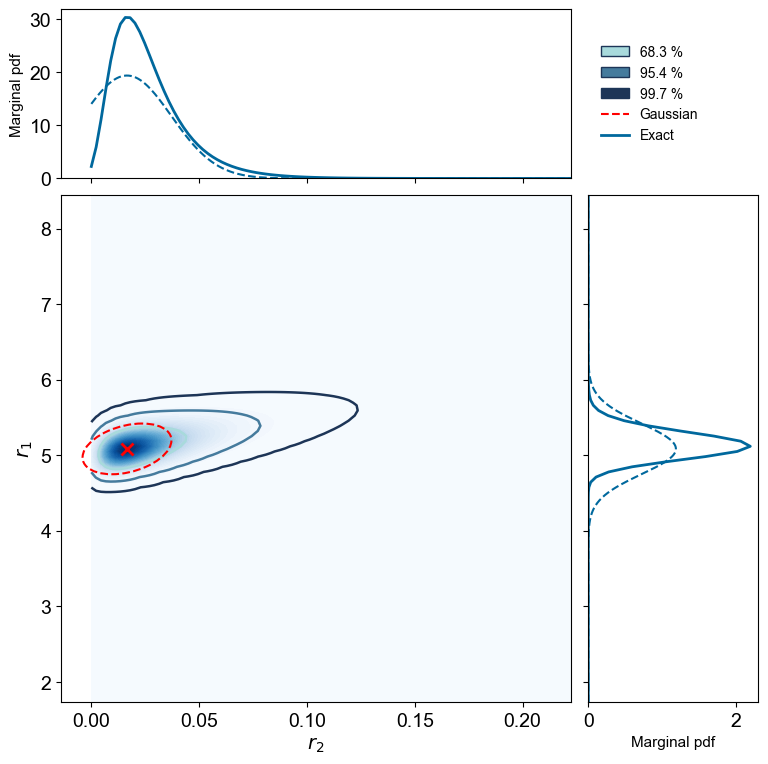

In [6]:
from matplotlib.patches import Ellipse
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(9, 9))
gs  = fig.add_gridspec(2, 2, hspace=0.05, wspace=0.05,
                       width_ratios=[3, 1], height_ratios=[1, 3])
ax_p1     = fig.add_subplot(gs[0, 0])           # top:   marginal r2
ax_2d     = fig.add_subplot(gs[1, 0], sharex=ax_p1)  # bottom-left: joint 2D
ax_p2     = fig.add_subplot(gs[1, 1], sharey=ax_2d)  # bottom-right: marginal r1
ax_legend = fig.add_subplot(gs[0, 1])           # top-right: legend panel
ax_legend.axis('off')

lc = '#00689D'   # line colour (matching the config)

# ── Joint 2D posterior (bottom-left) ─────────────────────────────────────
ax_2d.contourf(fit.parameter_x, fit.parameter_y, fit.posterior_grid.T,
               levels=50, cmap='Blues')
contour_levels = [fit.c3, fit.c2, fit.c1]
contour_colours = ['#1d3557', '#457b9d', '#a8dadc']
CS = ax_2d.contour(fit.parameter_x, fit.parameter_y, fit.posterior_grid.T,
                   levels=contour_levels, colors=contour_colours, linewidths=1.8)

# Gaussian ellipse from Fisher matrix
eigvals, eigvecs = np.linalg.eigh(invF)
angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
w, h  = 2 * np.sqrt(eigvals)   # ±1σ semi-axes
ell = Ellipse([r2_bf, r1_bf], width=w, height=h, angle=angle,
              edgecolor='red', facecolor='none', lw=1.5, ls='--', zorder=5)
ax_2d.add_patch(ell)
ax_2d.plot(r2_bf, r1_bf, 'x', color='red', ms=9, mew=2, zorder=6)
ax_2d.set_xlabel(r'$r_2$', fontsize=14)
ax_2d.set_ylabel(r'$r_1$', fontsize=14)

# ── Marginal for r2 (top-left) ────────────────────────────────────────────
marg_r2 = np.trapz(fit.posterior_grid, x=fit.parameter_y, axis=1)
marg_r2 /= np.trapz(marg_r2, x=fit.parameter_x)
ax_p1.plot(fit.parameter_x, marg_r2, color=lc, lw=2)
from scipy.stats import norm as spnorm
x_gauss = np.linspace(fit.parameter_x[0], fit.parameter_x[-1], 400)
ax_p1.plot(x_gauss, spnorm.pdf(x_gauss, r2_bf, sig_r2), color=lc, lw=1.5, ls='--')
ax_p1.set_ylabel('Marginal pdf', fontsize=11)
ax_p1.set_ylim(bottom=0)
plt.setp(ax_p1.get_xticklabels(), visible=False)

# ── Marginal for r1 (bottom-right) ───────────────────────────────────────
marg_r1 = np.trapz(fit.posterior_grid, x=fit.parameter_x, axis=0)
marg_r1 /= np.trapz(marg_r1, x=fit.parameter_y)
ax_p2.plot(marg_r1, fit.parameter_y, color=lc, lw=2)
y_gauss = np.linspace(fit.parameter_y[0], fit.parameter_y[-1], 400)
ax_p2.plot(spnorm.pdf(y_gauss, r1_bf, sig_r1), y_gauss, color=lc, lw=1.5, ls='--')
ax_p2.set_xlabel('Marginal pdf', fontsize=11)
ax_p2.set_xlim(left=0)
plt.setp(ax_p2.get_yticklabels(), visible=False)

# ── Legend in top-right panel ─────────────────────────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Patch(facecolor='#a8dadc', edgecolor='#1d3557', label='68.3 %'),
    Patch(facecolor='#457b9d', edgecolor='#1d3557', label='95.4 %'),
    Patch(facecolor='#1d3557', edgecolor='#1d3557', label='99.7 %'),
    Line2D([0],[0], color='red', ls='--', lw=1.5, label='Gaussian'),
    Line2D([0],[0], color=lc,   ls='-',  lw=2,   label='Exact'),
]
ax_legend.legend(handles=handles, fontsize=10, frameon=False, loc='center left')

plt.savefig('output/corner_plot_example.pdf', bbox_inches='tight')
plt.show()

### Reading the corner plot

**Joint 2D panel (bottom-left):**

| Contour shape | Meaning |
|---|---|
| Round/compact | Both parameters well-determined and independent |
| Elongated ellipse | $r_1$, $r_2$ correlated — many pairs fit similarly well |
| Banana-shaped | Strong non-linear correlation; Gaussian approximation fails |
| MLE near the edge | Skewed posterior — use true (asymmetric) credible intervals |

**When the dashed ellipse agrees with the solid contours:** the posterior is close to Gaussian
and you can report $\pm\sigma$ from the Fisher matrix.  
**When they disagree:** the true credible intervals are the only correct choice.

**1D marginal panels:**  
The marginals are the projections of the 2D posterior onto each axis.  Their 16th–84th percentile
span gives the asymmetric 68 % credible interval.  When the solid (exact) and dashed (Gaussian)
marginals overlap well, the Gaussian approximation is reliable.

---
## 8 — Residual diagnostics

<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_26724/2780338249.py:13: SyntaxWarning: invalid escape sequence '\,'
  label=f'MLE  $r_2={r2_bf:.3f},\, r_1={r1_bf:.3f}$')


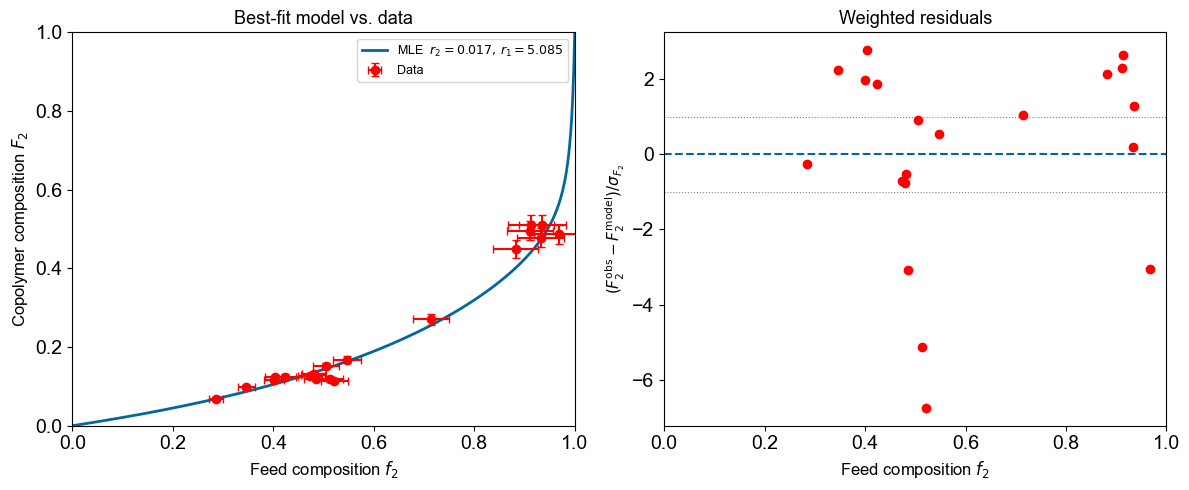

RMS weighted residual: 2.580
(≈ 1.0 if the uncertainty model is correct)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

Y_model   = np.array([mayo_lewis(fit.best_fit, x) for x in fit.data_X])
sigma_Y   = np.sqrt(np.diagonal(fit.CYY))
sigma_X   = np.sqrt(np.diagonal(fit.CXX))
w_res     = (fit.data_Y - Y_model) / sigma_Y

# Left: data + best-fit curve
ax = axes[0]
ax.errorbar(fit.data_X, fit.data_Y, yerr=sigma_Y, xerr=sigma_X,
            fmt='o', color='red', label='Data', capsize=3, zorder=5)
ax.plot(fit.Xfid, fit.Ybf, color='#00689D', lw=2,
        label=f'MLE  $r_2={r2_bf:.3f},\, r_1={r1_bf:.3f}$')
ax.set_xlabel(r'Feed composition $f_2$', fontsize=12)
ax.set_ylabel(r'Copolymer composition $F_2$', fontsize=12)
ax.set_title('Best-fit model vs. data', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Right: weighted residuals
ax = axes[1]
ax.axhline(0,  color='#00689D', lw=1.5, ls='--')
ax.axhline( 1, color='grey',    lw=0.8, ls=':')
ax.axhline(-1, color='grey',    lw=0.8, ls=':')
ax.scatter(fit.data_X, w_res, color='red', zorder=5)
ax.set_xlabel(r'Feed composition $f_2$', fontsize=12)
ax.set_ylabel(r'$(F_2^\mathrm{obs}-F_2^\mathrm{model})/\sigma_{F_2}$', fontsize=11)
ax.set_title('Weighted residuals', fontsize=13)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

rms = np.sqrt(np.mean(w_res**2))
print(f'RMS weighted residual: {rms:.3f}')
print('(≈ 1.0 if the uncertainty model is correct)')

**Reading the residual plot:**

Residuals divided by $\sigma_{F_2}$ are dimensionless. For a correctly specified model:

- Points scatter **randomly** around zero (no systematic trend).
- Most points fall within $\pm 1$ (grey dotted lines).
- RMS $\approx 1$.

| Pattern | Likely cause |
|---|---|
| Systematic curve (trend) | Model misspecified — e.g. penultimate-unit effects present |
| RMS $\gg 1$ | Uncertainties under-estimated |
| RMS $\ll 1$ | Uncertainties over-estimated |
| One outlier | Possible bad data point — check the experiment |

---
## 9 — PTE goodness-of-fit test

The **Probability To Exceed** (PTE) is a more rigorous goodness-of-fit test that avoids
the approximations implicit in $\chi^2/\text{dof}$.

It asks: *if the best-fit model were the true model, how often would a new experiment
produce a worse $\chi^2$ than the one observed?*

**Algorithm:**
1. Draw $N_\text{mock}$ synthetic datasets from $\mathcal{N}(\boldsymbol{\mu}_{\hat\theta},\,R(\hat\theta))$.
2. Re-fit each mock to get $\chi^2_\text{mock}$.
3. $\text{PTE} = $ fraction of mocks with $\chi^2_\text{mock} \geq \chi^2_\text{data}$.

| PTE | Interpretation |
|---|---|
| < 0.05 | Poor fit — model likely misspecified or errors too small |
| 0.05 – 0.95 | Acceptable fit |
| > 0.95 | Suspiciously good — errors may be over-estimated |

In [8]:
# Run the PTE test with 300 mocks (takes ~30 s for the Mayo-Lewis model)
pte, chi2_mocks = fit.run_pte_test(N_mock=300, output_file='output/pte_example.pdf', seed=42)

print(f'PTE = {pte:.3f}')
if pte < 0.05:
    print('  → Poor fit: model or error budget needs revision.')
elif pte > 0.95:
    print('  → Suspiciously good: errors may be over-estimated.')
else:
    print('  → Acceptable fit.')

Running PTE test with 300 mock realisations …
  100 / 300
  200 / 300
  300 / 300
PTE = 0.040  (χ²_data = -62.6400, median χ²_mock = -68.7222)
PTE = 0.040
  → Poor fit: model or error budget needs revision.


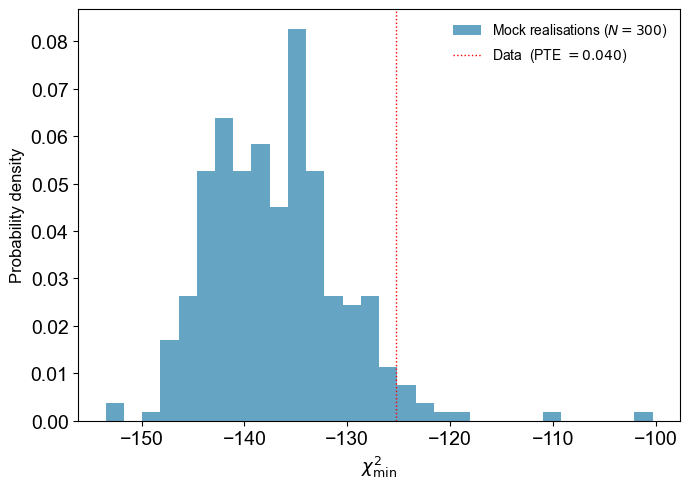

In [9]:
# Reproduce the PTE histogram manually.
# run_pte_test stores chi_square() values (= chi²/2 internally); multiply by 2
# so the x-axis matches the conventional chi² statistic.
chi2_mocks_full = 2.0 * chi2_mocks
chi2_data_full  = 2.0 * fit.max_func

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(chi2_mocks_full, bins=30, density=True, color='#00689D', alpha=0.6,
        label=f'Mock realisations ($N={len(chi2_mocks_full)}$)')
ax.axvline(chi2_data_full, color='red', lw=1, ls=':',
           label=f'Data  (PTE $= {pte:.3f}$)')
ax.set_xlabel(r'$\chi^2_\mathrm{min}$', fontsize=13)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_ylim(bottom=0)
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

The dotted vertical line shows where the data's $\chi^2$ falls in the distribution
of mock values.  If it falls in the centre the model is a typical realisation of the data.
If it falls in the far right tail the data fit too well; far left tail means poor fit.

---
## 10 — The Skeist model (high conversion)

### Why Mayo-Lewis fails at high conversion

The Mayo-Lewis equation gives the **instantaneous** copolymer composition for a **fixed** feed:

$$F(f) = \frac{r_2 f^2 + f(1-f)}{r_2 f^2 + 2f(1-f) + r_1(1-f)^2}$$

At conversion $X > 5\,\%$ the feed drifts — the more reactive monomer is consumed faster and
$f$ changes continuously.  Applying Mayo-Lewis with a single $f_0$ then gives biased estimates.

### The Skeist integrated equation

Skeist (1953) derived how $f$ evolves with conversion:

$$\ln(1-X) = \int_{f_0}^{f} \frac{\mathrm{d}f'}{F(f') - f'}$$

Given $(r_1,r_2)$, initial feed $f_0$, and conversion $X$, this is solved numerically for
$f_\text{final}$.  The **cumulative** copolymer composition — what NMR measures on the
bulk product — follows from a mass balance:

$$F_\text{cum} = \frac{f_0 - f_\text{final}\,(1-X)}{X}$$

### EVM derivatives for the Skeist model

The Skeist model needs two derivatives for full error propagation:

$$\frac{\partial F_\text{cum}}{\partial X} = \frac{F(f_\text{final}) - F_\text{cum}}{X}
\qquad\text{(from Leibniz rule + mass balance)}$$

$$\frac{\partial F_\text{cum}}{\partial f_0} = \frac{1}{X}\left[1 - \frac{F(f_\text{final})-f_\text{final}}{F(f_0)-f_0}\,(1-X)\right]
\qquad\text{(for propagating } f_0 \text{ uncertainty)}$$

Both are analytical (no finite differences) and are provided in `source.models`.

In [10]:
from source.models import skeist, skeist_deriv, skeist_deriv_f0

print('Skeist example config:')
with open('examples/skeist_example.ini') as fh:
    print(fh.read())

Skeist example config:
# polyfit — example config for the Skeist high-conversion model
# Use this when fractional conversion X > ~5 %.
#
# Run with:   python main.py examples/skeist_example.ini
#
# The Skeist model integrates the Mayo-Lewis equation over the full
# conversion path.  Each data point requires both an initial feed
# composition f0 and a fractional conversion X_conv — use a CSV file.
#
# ──────────────────────────────────────────────────────────────────────────

[data_structure]

# Path to the data file.  For the Skeist model a CSV file is required
# because each data point needs its own f0 value.
#
# CSV 4-col (.csv) — f0, X_conv, F_cum, dF_cum
# CSV 5-col (.csv) — f0, X_conv, dX_conv, F_cum, dF_cum
# CSV 6-col (.csv) — f0, X_conv, dX_conv, F_cum, dF_cum, df0
#
#   f0      = initial mole fraction of M2 in the feed
#   X_conv  = fractional monomer conversion (0–1)
#   dX_conv = absolute 1σ uncertainty on X_conv
#   F_cum   = cumulative copolymer mole fraction of M2
#   dF_

Optimization terminated successfully.
         Current function value: -86.108301
         Iterations: 66
         Function evaluations: 129
creating posterior grid
  100/100 rows


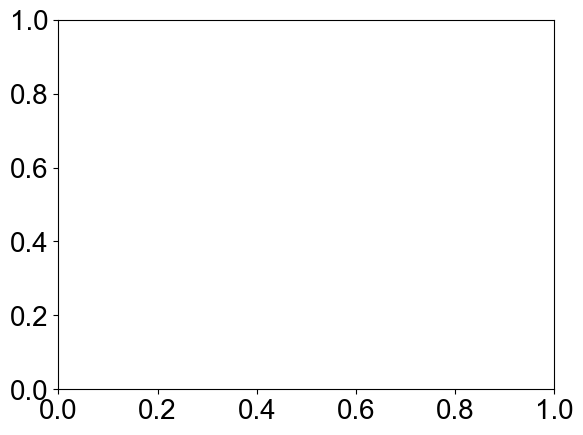

In [11]:
# Run the Skeist fit on the IUPAC reference dataset
# derivative_model_f0 activates f0-error propagation via dF_cum/df0
fit_s = FitModel(skeist, skeist_deriv, 'examples/skeist_example.ini',
                 derivative_model_f0=skeist_deriv_f0)

In [12]:
r2_s, r1_s = fit_s.best_fit

invF_s  = np.linalg.inv(fit_s.fisher_at_bf)
sig_r2s = np.sqrt(invF_s[0, 0])
sig_r1s = np.sqrt(invF_s[1, 1])
corr_s  = invF_s[0, 1] / (sig_r2s * sig_r1s)

r2s_lo = r2_s - fit_s.p1_cdf_marginal_spline(0.159)
r2s_hi = fit_s.p1_cdf_marginal_spline(0.841) - r2_s
r1s_lo = r1_s - fit_s.p2_cdf_marginal_spline(0.159)
r1s_hi = fit_s.p2_cdf_marginal_spline(0.841) - r1_s

print('Skeist fit — IUPAC dataset')
print('=' * 50)
print(f'  r2 = {r2_s:.4f}   Gaussian ± {sig_r2s:.4f}')
print(f'         True 68 % : −{r2s_lo:.4f}  /  +{r2s_hi:.4f}')
print(f'  r1 = {r1_s:.4f}   Gaussian ± {sig_r1s:.4f}')
print(f'         True 68 % : −{r1s_lo:.4f}  /  +{r1s_hi:.4f}')
print(f'  ρ(r2,r1) = {corr_s:+.3f}')
print(f'  χ²/dof  = {2*fit_s.max_func/max(fit_s.number_of_data_points-2,1):.3f}')

Skeist fit — IUPAC dataset
  r2 = 0.3997   Gaussian ± 0.0792
         True 68 % : −0.0351  /  +0.0448
  r1 = 0.0214   Gaussian ± 0.0091
         True 68 % : −0.0036  /  +0.0050
  ρ(r2,r1) = +0.106
  χ²/dof  = -5.939


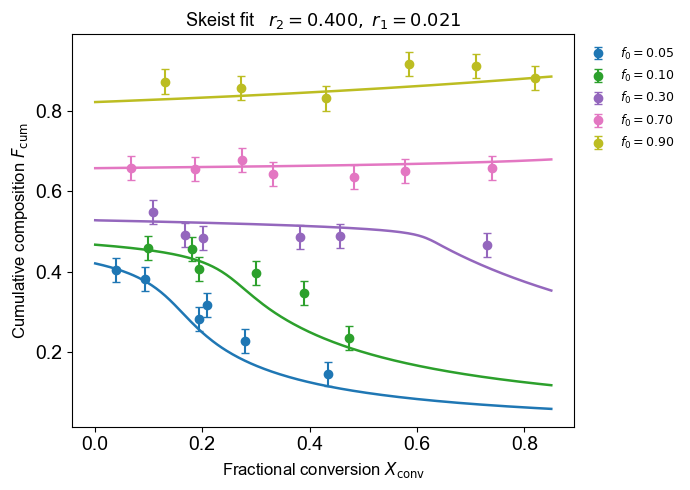

In [13]:
# Best-fit curves grouped by initial feed f0
model_x   = np.array(list(fit_s._model_x))    # shape (N, 2): col0=f0, col1=X_conv
f0_all    = model_x[:, 0]
f0_values = np.unique(f0_all)
colors    = plt.cm.tab10(np.linspace(0, 0.8, len(f0_values)))

fig, ax = plt.subplots(figsize=(7, 5))
X_range = np.linspace(0.001, 0.85, 300)

for i, f0_val in enumerate(f0_values):
    mask  = np.isclose(f0_all, f0_val)
    X_pts = model_x[mask, 1]
    F_pts = fit_s.data_Y[mask]
    dF    = np.sqrt(np.diagonal(fit_s.CYY))[mask]
    ax.errorbar(X_pts, F_pts, yerr=dF, fmt='o', color=colors[i], capsize=3,
                label=f'$f_0 = {f0_val:.2f}$')
    Y_curve = [skeist(fit_s.best_fit, [f0_val, X]) for X in X_range]
    ax.plot(X_range, Y_curve, color=colors[i], lw=1.8)

ax.set_xlabel(r'Fractional conversion $X_\mathrm{conv}$', fontsize=12)
ax.set_ylabel(r'Cumulative composition $F_\mathrm{cum}$', fontsize=12)
ax.set_title(f'Skeist fit   $r_2={r2_s:.3f},\\; r_1={r1_s:.3f}$', fontsize=13)
ax.legend(fontsize=9, frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.savefig('output/skeist_fit_example.pdf', bbox_inches='tight')
plt.show()

Each coloured group of points comes from a different initial feed composition $f_0$.
The Skeist model predicts a different $F_\text{cum}(X)$ curve for each $f_0$ — the curves
diverge at high conversion as the feeds drift in different directions depending on the
reactivity ratios.

> **Performance note:** the Skeist model solves a numerical integral for every data point
> at every grid node.  Use `N_inter ≤ 150` for reasonable run times.
> The posterior grid is parallelised across CPU cores automatically.

---
## 11 — Reporting results for publication

### Recommended number format

In [14]:
print('Mayo-Lewis fit (data/data.txt):')
print(f'  r2 = {r2_bf:.3f}  +{r2_hi:.3f} / -{r2_lo:.3f}   (68 % credible interval)')
print(f'  r1 = {r1_bf:.3f}  +{r1_hi:.3f} / -{r1_lo:.3f}   (68 % credible interval)')
print()
print('Skeist fit (IUPAC dataset):')
print(f'  r2 = {r2_s:.3f}  +{r2s_hi:.3f} / -{r2s_lo:.3f}   (68 % credible interval)')
print(f'  r1 = {r1_s:.3f}  +{r1s_hi:.3f} / -{r1s_lo:.3f}   (68 % credible interval)')

Mayo-Lewis fit (data/data.txt):
  r2 = 0.017  +0.025 / -0.005   (68 % credible interval)
  r1 = 5.085  +0.245 / -0.129   (68 % credible interval)

Skeist fit (IUPAC dataset):
  r2 = 0.400  +0.045 / -0.035   (68 % credible interval)
  r1 = 0.021  +0.005 / -0.004   (68 % credible interval)


### Example methods text

> Reactivity ratios were determined by maximum-likelihood fitting of the Skeist integrated
> equation to the experimental $(f_0,\,X_\text{conv},\,F_\text{cum})$ data using polyfit
> (Reischke 2023), propagating a 3 % relative uncertainty on $F_\text{cum}$ through the
> Errors-in-Variables effective covariance matrix.  The best-fit values are
> $r_2 = X.XXX^{+0.XXX}_{-0.XXX}$ and $r_1 = X.XXX^{+0.XXX}_{-0.XXX}$ (68 % credible
> intervals from the marginal posterior distributions; joint 95 % and 99.7 % credible
> regions are shown in Figure X).  A PTE test with 200 mock datasets yielded PTE $= 0.XX$,
> indicating an acceptable fit.

### Common pitfalls

| Issue | Symptom | Fix |
|---|---|---|
| Prior range too narrow | MLE near the grid boundary | Widen `prior_range` and rerun |
| `N_inter` too small | Jagged contour lines | Increase to 200–500 |
| $X$ uncertainty ignored | Biased $r_1$, $r_2$ when $dF/df$ is large | Set `X_covariance` |
| Errors underestimated | RMS $\gg 1$, PTE $\ll 0.05$ | Use more realistic uncertainties |
| Errors overestimated | RMS $\ll 1$, PTE $\gg 0.95$ | Check your error budget |
| Too few data points | Elongated, poorly constrained posterior | Add data at extreme feed compositions |
| Mayo-Lewis at high conversion | Biased $r_1$, $r_2$; poor residuals | Switch to `high_conversion = true` |

---
## Reference

> R. Reischke, *Macromolecular Theory and Simulations* **32** (2023) 2200063.  
> DOI: [10.1002/mats.202200063](https://onlinelibrary.wiley.com/doi/10.1002/mats.202200063)